# 04 — Treatment effects

**Purpose.** Estimate what the two email campaigns actually caused, attach honest
uncertainty to each estimate, and correct for the fact that six tests are being run
at once.

Feature 3 cleared the way for this. The randomisation held — no sample ratio
mismatch, no covariate imbalance, covariates jointly explaining 0.02% of assignment —
so a difference in means between arms is an unbiased estimate of the causal effect of
*being sent* an email.

The method is chosen by outcome type:

| Outcome | Nature | Test | Why |
|---|---|---|---|
| `visit` | Binary | Two-proportion z-test | Standard for a difference in rates |
| `conversion` | Binary | Two-proportion z-test | Same, though the base rate is under 1% |
| `spend` | Continuous, ~99% zeros | Welch's t-test + bootstrap | Skew severe enough to verify, not assume |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.load import load_processed, make_comparison_frame
from src.analysis.ab_test import run_ab_tests, bootstrap_effect, estimate_effect

pd.set_option("display.width", 140)
df = load_processed()
results = run_ab_tests(df, save=False)
print(f"{len(results)} tests: {len(config.OUTCOMES)} outcomes x "
      f"{len(config.COMPARISONS)} treatment arms")

6 tests: 3 outcomes x 2 treatment arms


## 1. The headline result

In [2]:
display = results[[
    "treatment_arm", "outcome", "control_mean", "treated_mean",
    "absolute_effect", "ci_low", "ci_high", "relative_effect",
    "p_value", "p_value_adjusted", "significant",
]]
display.style.format({
    "control_mean": "{:.4f}",
    "treated_mean": "{:.4f}",
    "absolute_effect": "{:+.4f}",
    "ci_low": "{:+.4f}",
    "ci_high": "{:+.4f}",
    "relative_effect": "{:+.1%}",
    "p_value": "{:.2e}",
    "p_value_adjusted": "{:.2e}",
}).hide(axis="index")

treatment_arm,outcome,control_mean,treated_mean,absolute_effect,ci_low,ci_high,relative_effect,p_value,p_value_adjusted,significant
Mens E-Mail,visit,0.1062,0.1828,+0.0766,+0.0700,+0.0832,+72.1%,5.69e-112,3.41e-111,True
Mens E-Mail,conversion,0.0057,0.0125,+0.0068,+0.0050,+0.0086,+118.8%,1.52e-13,6.09e-13,True
Mens E-Mail,spend,0.6528,1.4226,+0.7698,+0.4851,+1.0545,+117.9%,1.16e-07,3.49e-07,True
Womens E-Mail,visit,0.1062,0.1514,+0.0452,+0.0389,+0.0516,+42.6%,3.18e-44,1.59e-43,True
Womens E-Mail,conversion,0.0057,0.0088,+0.0031,+0.0015,+0.0047,+54.3%,1.57e-04,3.14e-04,True
Womens E-Mail,spend,0.6528,1.0772,+0.4244,+0.1690,+0.6799,+65.0%,1.13e-03,1.13e-03,True


**Both campaigns worked, on every outcome, and every effect survives correction
for multiple testing.** No result here is marginal — the weakest p-value in the table
is 0.0011, and the strongest is on the order of 1e-112.

Reading the Mens E-Mail row for visits: the campaign raised the visit rate from 10.6%
to 18.3%, an absolute increase of 7.7 percentage points, with 95% confidence that the
true effect lies between 7.0 and 8.3 points.

### Absolute versus relative effects

The two columns tell different stories and both matter:

- **Absolute** is what the business feels. Conversion rose by 0.68 percentage points
  — which sounds small, and on 21,307 customers is roughly 145 extra purchases.
- **Relative** is what makes the headline. That same 0.68 points is a **+119%**
  increase, because the base rate is only 0.57%.

Quoting only the relative figure on a low base rate is one of the most common ways to
oversell a result. Quoting only the absolute figure buries a genuine doubling. Both
are reported.

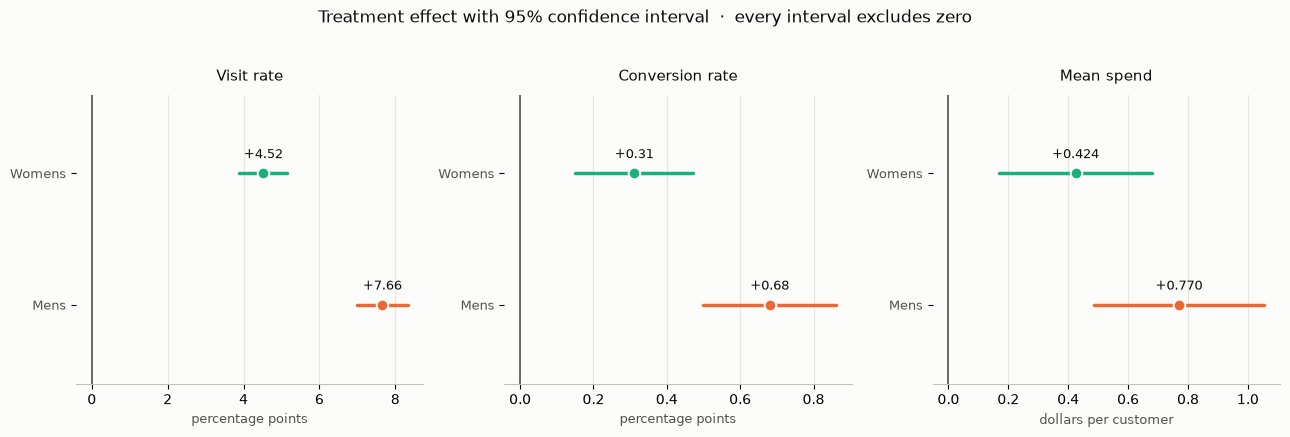

In [3]:
# One panel per outcome: the three outcomes are on incomparable scales
# (percentage points vs dollars), so they get independent axes rather than
# being forced together.
ARM_COLOURS = {"Mens E-Mail": "#eb6834", "Womens E-Mail": "#1baf7a"}
PANELS = [
    ("visit", "Visit rate", 100, "{:+.2f} pp", "percentage points"),
    ("conversion", "Conversion rate", 100, "{:+.3f} pp", "percentage points"),
    ("spend", "Mean spend", 1, "{:+$.3f}".replace("$", ""), "dollars per customer"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
fig.patch.set_facecolor("#fcfcfb")

for ax, (outcome, title, scale, fmt, unit) in zip(axes, PANELS):
    subset = results[results["outcome"] == outcome]
    arms = list(ARM_COLOURS)
    positions = range(len(arms))

    for position, arm in zip(positions, arms):
        row = subset[subset["treatment_arm"] == arm].iloc[0]
        effect = row["absolute_effect"] * scale
        low, high = row["ci_low"] * scale, row["ci_high"] * scale

        ax.plot([low, high], [position, position],
                color=ARM_COLOURS[arm], linewidth=2.5, zorder=3,
                solid_capstyle="round")
        ax.scatter([effect], [position], s=70, color=ARM_COLOURS[arm],
                   zorder=4, edgecolor="#fcfcfb", linewidth=1.4)
        label = f"{effect:+.2f}" if outcome != "spend" else f"{effect:+.3f}"
        ax.annotate(label, (effect, position), xytext=(0, 11),
                    textcoords="offset points", ha="center",
                    fontsize=9, color="#0b0b0b")

    ax.axvline(0, color="#52514e", linewidth=1.2, zorder=2)
    ax.set_facecolor("#fcfcfb")
    ax.set_yticks(list(positions))
    ax.set_yticklabels(["Mens", "Womens"], fontsize=9, color="#52514e")
    ax.set_ylim(-0.6, len(arms) - 0.4)
    ax.set_title(title, fontsize=11, color="#0b0b0b", pad=10)
    ax.set_xlabel(unit, fontsize=9, color="#52514e")
    ax.grid(axis="x", color="#e6e5e1", linewidth=0.8, zorder=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")

fig.suptitle(
    "Treatment effect with 95% confidence interval  ·  every interval excludes zero",
    fontsize=12, color="#0b0b0b", y=1.03,
)
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "04_treatment_effects.png", dpi=150, bbox_inches="tight",
            facecolor="#fcfcfb")
plt.show()

Every interval sits entirely to the right of zero, and Mens E-Mail beats Womens
E-Mail on all three outcomes. The intervals for the two arms do not overlap on visits,
which is a meaningful gap; on spend they overlap substantially, so the apparent
superiority there is much less certain.

## 2. Which standard error goes where

The two-proportion z-test uses **two different standard errors**, and conflating them
is the most common error in an otherwise correct implementation:

- The **test statistic** assumes the null hypothesis — that both arms share one
  underlying rate. The best estimate of that shared rate is the pooled proportion, so
  the null standard error is computed from it.
- The **confidence interval** assumes nothing. It describes a range of plausible
  *non-zero* differences, so pooling the arms would mean assuming the very thing being
  estimated. It uses the unpooled standard error.

Using the pooled SE for both produces an interval that can contradict its own p-value
near the significance boundary.

In [4]:
comparison = make_comparison_frame(df, config.MENS_ARM)
treated = comparison.loc[comparison["treated"] == 1, "conversion"]
control = comparison.loc[comparison["treated"] == 0, "conversion"]

n_t, n_c = len(treated), len(control)
p_t, p_c = treated.mean(), control.mean()

p_pooled = (treated.sum() + control.sum()) / (n_t + n_c)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n_t + 1 / n_c))
se_unpooled = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)

print(f"Pooled SE   (used for the test)     : {se_pooled:.8f}")
print(f"Unpooled SE (used for the interval) : {se_unpooled:.8f}")
print(f"Difference                          : {abs(se_pooled - se_unpooled):.8f}"
      f"  ({abs(se_pooled - se_unpooled) / se_unpooled:.1%})")

Pooled SE   (used for the test)     : 0.00092145
Unpooled SE (used for the interval) : 0.00092085
Difference                          : 0.00000060  (0.1%)


Here the two differ by only 0.1%, because the arms are large and the rates are
both small — the pooled and unpooled variances nearly coincide. The distinction is
irrelevant to *this* result and would be equally irrelevant if it were skipped.

That is exactly why it is worth being deliberate about. The gap widens when the two
rates are far apart or the arms are unequal in size, and a result sitting near
p = 0.05 is where an interval that disagrees with its own p-value does damage. Getting
it right here costs nothing; having the habit is what pays.

## 3. Is the normal approximation safe for spend?

Spend is the awkward outcome: **99.1% of customers spend exactly \$0**, and the
standard deviation is roughly 14x the mean. Welch's t-test relies on the central limit
theorem, which should hold at n > 21,000 — but "should" is worth checking when the
skew is this extreme.

So the analytic interval is compared against a percentile bootstrap, which assumes
nothing about the shape of the distribution.

In [5]:
boot_rows = []
for arm, control_arm in config.COMPARISONS:
    frame = make_comparison_frame(df, arm, control_arm)
    boot = bootstrap_effect(
        frame.loc[frame["treated"] == 1, "spend"],
        frame.loc[frame["treated"] == 0, "spend"],
    )
    analytic = results[(results["treatment_arm"] == arm)
                       & (results["outcome"] == "spend")].iloc[0]
    boot_rows.append({
        "arm": arm,
        "effect": analytic["absolute_effect"],
        "welch_low": analytic["ci_low"],
        "welch_high": analytic["ci_high"],
        "boot_low": boot["absolute_ci_low"],
        "boot_high": boot["absolute_ci_high"],
        "rel_low": boot["relative_ci_low"],
        "rel_high": boot["relative_ci_high"],
    })

pd.DataFrame(boot_rows).style.format({
    "effect": "${:+.4f}",
    "welch_low": "${:+.4f}", "welch_high": "${:+.4f}",
    "boot_low": "${:+.4f}", "boot_high": "${:+.4f}",
    "rel_low": "{:+.1%}", "rel_high": "{:+.1%}",
}).hide(axis="index")

arm,effect,welch_low,welch_high,boot_low,boot_high,rel_low,rel_high
Mens E-Mail,$+0.7698,$+0.4851,$+1.0545,$+0.4875,$+1.0589,+63.9%,+195.6%
Womens E-Mail,$+0.4244,$+0.1690,$+0.6799,$+0.1689,$+0.6821,+22.1%,+126.2%


**The two intervals agree to within a fraction of a cent.** The central limit
theorem is doing its job: 21,000 observations is enough to normalise the sampling
distribution of the mean even when the underlying data is 99% zeros.

This is a genuine finding, not a formality. Had they disagreed, the bootstrap interval
would have been the one to report, and the t-test result would have been misleading.
Checking cost 10,000 resamples and bought the right to trust the simpler method.

### Why bootstrap the relative effect too

A relative effect is a ratio of two random quantities. Dividing the absolute CI by the
control mean would treat the denominator as a known constant, understating the
uncertainty by ignoring its variability. Resampling handles both at once — and the
result is striking:

- Mens E-Mail spend: point estimate **+118%**, interval **[+64%, +196%]**
- Womens E-Mail spend: point estimate **+65%**, interval **[+22%, +126%]**

The *direction* is certain — both intervals exclude zero — but the *magnitude* is not
pinned down within a factor of three. A slide claiming "email doubles spend" is
defensible only if it also says "somewhere between a 60% and a 200% increase."

## 4. Correcting for six tests

Six tests are run: three outcomes across two arms. If no campaign did anything and
each test ran at α = 0.05, the chance of at least one false positive would be
1 − 0.95⁶ ≈ **26%**. That is not a small risk to leave unmanaged.

In [6]:
from statsmodels.stats.multitest import multipletests

raw = results["p_value"].to_numpy()
holm = multipletests(raw, alpha=config.ALPHA, method="holm")[1]
bonferroni = multipletests(raw, alpha=config.ALPHA, method="bonferroni")[1]
bh = multipletests(raw, alpha=config.ALPHA, method="fdr_bh")[1]

pd.DataFrame({
    "arm": results["treatment_arm"],
    "outcome": results["outcome"],
    "raw p": raw,
    "Holm (used)": holm,
    "Bonferroni": bonferroni,
    "Benjamini-Hochberg": bh,
}).style.format({
    "raw p": "{:.3e}", "Holm (used)": "{:.3e}",
    "Bonferroni": "{:.3e}", "Benjamini-Hochberg": "{:.3e}",
}).hide(axis="index")

arm,outcome,raw p,Holm (used),Bonferroni,Benjamini-Hochberg
Mens E-Mail,visit,5.685e-112,3.411e-111,3.411e-111,3.411e-111
Mens E-Mail,conversion,1.523e-13,6.093e-13,9.139e-13,3.046e-13
Mens E-Mail,spend,1.164e-07,3.491e-07,6.983e-07,1.746e-07
Womens E-Mail,visit,3.182e-44,1.591e-43,1.909e-43,9.547e-44
Womens E-Mail,conversion,1.571e-04,3.142e-04,9.426e-04,1.885e-04
Womens E-Mail,spend,1.129e-03,1.129e-03,6.776e-03,1.129e-03


**Holm is used, not Bonferroni.** Both control the family-wise error rate — the
probability of *any* false positive — but Holm is uniformly more powerful: it never
rejects fewer hypotheses than Bonferroni and sometimes rejects more. Choosing
Bonferroni would be discarding power for nothing. The table shows Holm's adjusted
values at or below Bonferroni's on every row.

Benjamini-Hochberg is shown for contrast. It controls the *false discovery rate* — the
expected share of rejections that are wrong — which is a weaker guarantee and the right
one when screening hundreds of hypotheses for follow-up. With six pre-specified
outcomes that will be acted on directly, controlling FWER is the appropriate choice.

In this case the decision is academic: every effect is so strong that all three
corrections agree. It matters that the choice was made deliberately rather than
because the answer came out the same.

## 5. Could these tests have found nothing?

A test that always rejects is not evidence. Below, the control arm is split randomly
in half and one half is *labelled* as treated. There is no treatment, so the correct
answer is a null result.

In [7]:
rng = np.random.default_rng(config.RANDOM_SEED)
placebo = df[df[config.TREATMENT_COL] == config.CONTROL_ARM].copy()
half = rng.random(len(placebo)) < 0.5
placebo[config.TREATMENT_COL] = pd.Categorical(
    np.where(half, config.MENS_ARM, config.CONTROL_ARM),
    categories=[config.CONTROL_ARM, config.MENS_ARM, config.WOMENS_ARM],
)

print("Placebo test - control arm split at random, no treatment applied:\n")
for outcome in config.OUTCOMES:
    est = estimate_effect(placebo, outcome, config.MENS_ARM)
    print(f"  {outcome:<11} effect = {est.absolute_effect:+.5f}   "
          f"95% CI = [{est.ci_low:+.5f}, {est.ci_high:+.5f}]   "
          f"p = {est.p_value:.3f}")

Placebo test - control arm split at random, no treatment applied:

  visit       effect = -0.00321   95% CI = [-0.01148, +0.00506]   p = 0.447
  conversion  effect = -0.00029   95% CI = [-0.00231, +0.00174]   p = 0.783
  spend       effect = +0.15064   95% CI = [-0.16116, +0.46244]   p = 0.344


All three p-values are unremarkable and every interval comfortably contains zero.
The machinery finds nothing when there is nothing to find, which is what makes the
real results above meaningful. The test suite asserts this property rather than
relying on this one demonstration.

## Results

| Arm | Outcome | Effect | 95% CI | Relative | Holm p |
|---|---|---|---|---|---|
| Mens | Visit | +7.66 pp | [+7.00, +8.32] | +72% | 3e-111 |
| Mens | Conversion | +0.68 pp | [+0.50, +0.86] | +119% | 6e-13 |
| Mens | Spend | +\$0.77 | [+0.49, +1.05] | +118% | 3e-07 |
| Womens | Visit | +4.52 pp | [+3.89, +5.16] | +43% | 2e-43 |
| Womens | Conversion | +0.31 pp | [+0.15, +0.47] | +54% | 3e-04 |
| Womens | Spend | +\$0.42 | [+0.17, +0.68] | +65% | 1e-03 |

**Both campaigns caused real increases in every outcome.** Mens E-Mail is roughly
twice as effective as Womens E-Mail on visits and conversion.

Three caveats that shape what comes next:

1. **The relative effect on spend is imprecise** — certain in direction, uncertain
   within a factor of three in magnitude. Feature 6 uses CUPED to try to tighten it.
2. **These are average effects.** An average positive effect is entirely consistent
   with a substantial group of customers being *put off* by the email. Features 7-9
   look for exactly that.
3. **Nothing here says the campaign was profitable.** An effect can be real and still
   cost more to produce than it returns. Feature 10 does that arithmetic.

**Next — Feature 5:** power and minimum detectable effect. The effects here were
found easily, which raises the question of what size of effect this experiment could
*not* have detected — and whether the spend result was lucky rather than well-powered.